## Implementation of Polynomial Regression

#### Importing Essential Libraries

In [59]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

#### Creating Feature and Dependent Variable using random()

In [60]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)
# y = 0.8x^2 + 0.9x + 2

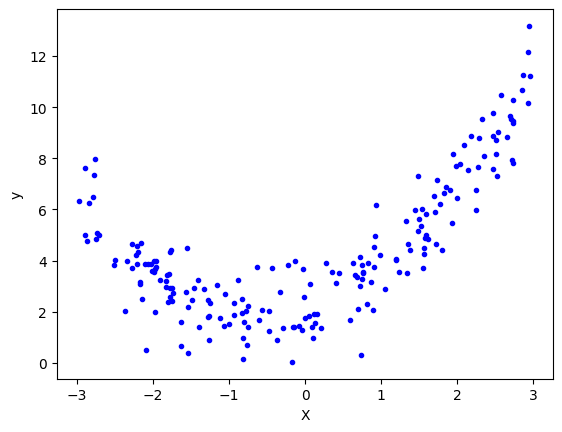

In [61]:
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

#### First training data with Linear Regression model and Comparing r2_score

In [62]:
model_lin = LinearRegression()

In [63]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [64]:
model_lin.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
y_pred_lin = model_lin.predict(X_test)

In [66]:
r2_score(y_test,y_pred_lin)

0.30529128972156105

In [67]:
model_lin.coef_

array([[0.94168215]])

In [68]:
model_lin.intercept_

array([4.3105519])

In [69]:
Y_plot = model_lin.coef_*X_train+model_lin.intercept_

#### Plotting best fit line to the datapoints

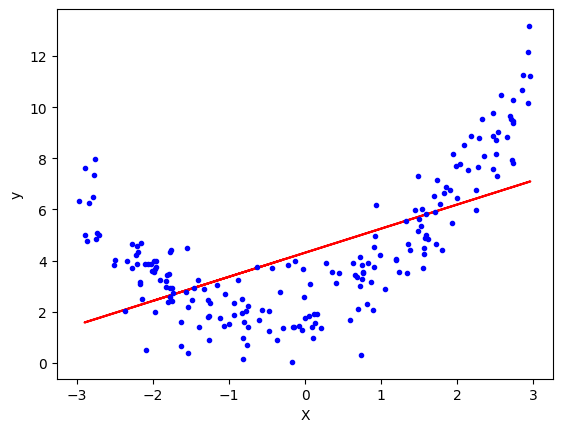

In [70]:
plt.plot(X_train,Y_plot,color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Applying Polynomial Function

#### Transforming the data 

In [71]:
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.fit_transform(X_test)

In [72]:
print(X_train[0])
print(X_train_trans[0])

[-1.98956355]
[ 1.         -1.98956355  3.9583631 ]


In [73]:
model_poly = LinearRegression()


In [74]:
model_poly.fit(X_train_trans,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [75]:
y_pred_poly = model_poly.predict(X_test_trans)

In [76]:
r2_score(y_test,y_pred_poly)

0.8499838110752032

In [77]:
model_poly.coef_.shape

(1, 3)

In [78]:
coeff = model_poly.coef_
coeff = coeff.ravel()

In [79]:
model_poly.intercept_

array([2.06419389])

In [80]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = model_poly.predict(X_new_poly)

#### Plotting datapoints with the best fit curve

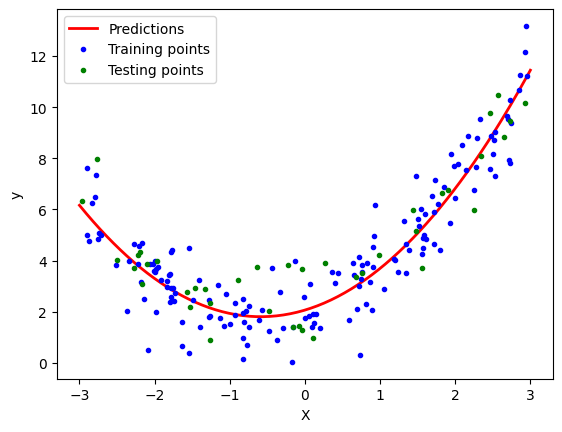

In [81]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

#### Conclusion: 
```Model``` | ```r2_score```

``` LinearRegression ``` | ```0.170```

``` PolynomialRegression (degree=2)``` | ```0.85```

#### Code from scratch

In [82]:
# a = X^-1 * B

In [83]:
class My_PolynomialRegression:

    def __init__(self, degree=2):
        self.degree = degree
        self.X_X = np.zeros((degree+1, degree+1))
        self.B = np.zeros((degree+1, 1))
        self.a = None

    def fit(self, X_train, y_train):

        for i in range(self.degree+1):
            for j in range(self.degree+1):
                self.X_X[i, j] = np.sum(X_train**(i+j))

        for i in range(self.degree+1):
            self.B[i] = np.sum((X_train**i) * y_train)

        self.a = (np.linalg.inv(self.X_X) @ self.B).ravel()

    def predict(self, X_test):

        y_pred = np.zeros_like(X_test, dtype=float)

        for i in range(len(self.a)):
            y_pred += self.a[i] * (X_test**i)

        return y_pred

In [94]:
my_poly = My_PolynomialRegression()
my_poly.fit(X_train,y_train)

In [95]:
y_predicted_values = my_poly.predict(X_test)

In [96]:
r2_score(y_test,y_predicted_values)

0.8499838110752032

#### Hence the r2_score of X inverse * B and using built in library is same.